In [62]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings("ignore")
import fasttext

In [12]:
from scipy.stats import anderson

In [5]:
train = pl.read_parquet("../data/train_sample.parquet")

# Target Distribution Analysis

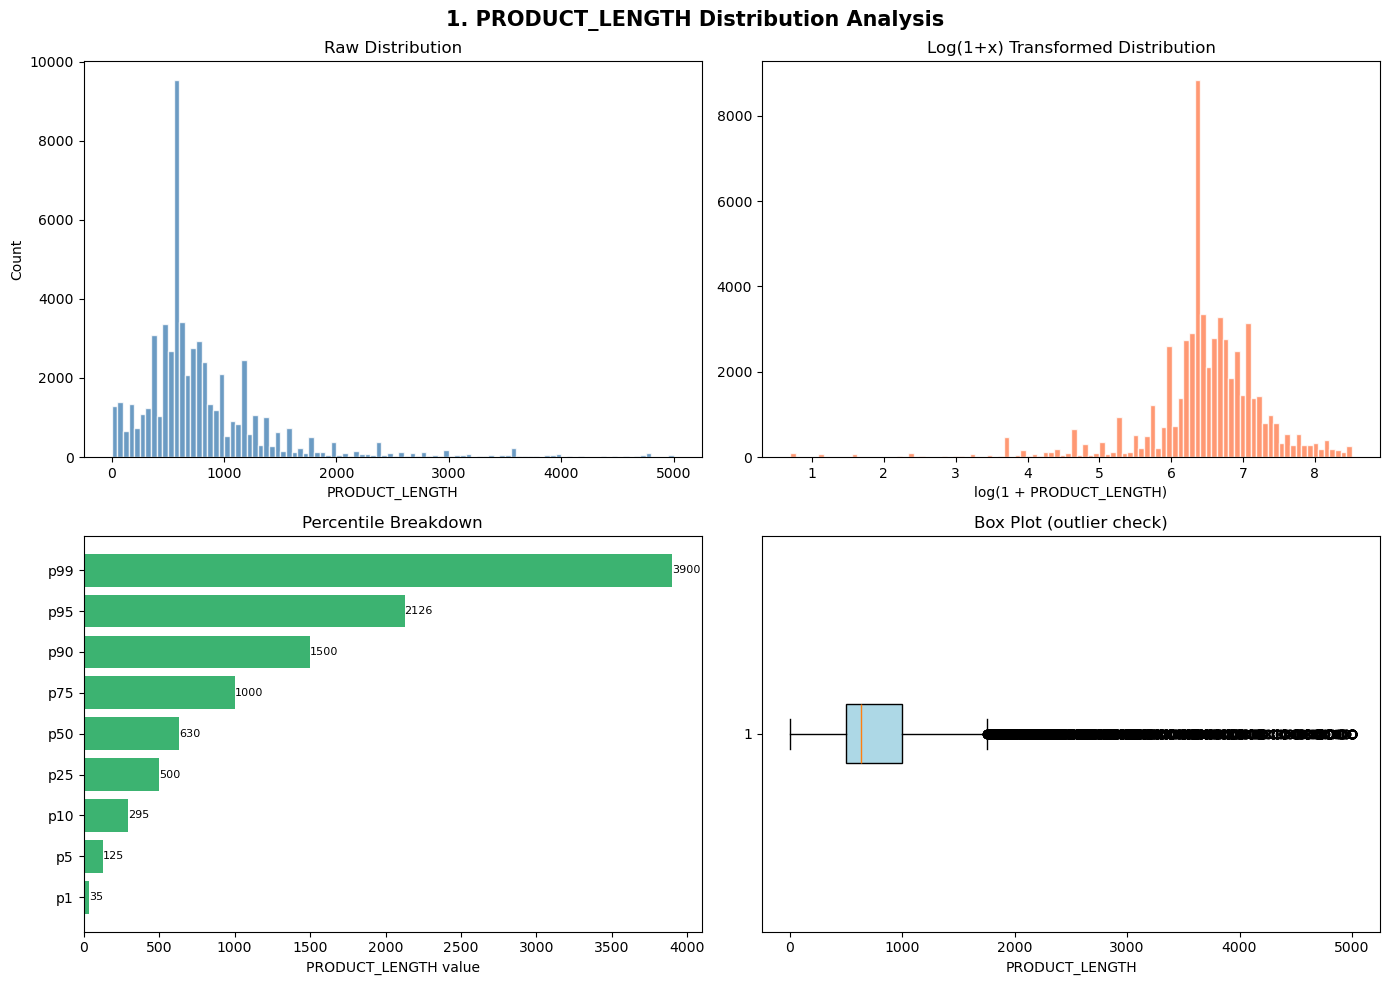

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("1. PRODUCT_LENGTH Distribution Analysis", fontsize=15, fontweight="bold")
# 1a. Raw distribution
axes[0, 0].hist(train["PRODUCT_LENGTH"], bins=100, color="steelblue", edgecolor="white", alpha=0.8)
axes[0, 0].set_title("Raw Distribution")
axes[0, 0].set_xlabel("PRODUCT_LENGTH")
axes[0, 0].set_ylabel("Count")
# 1b. Log-transformed distribution
log_vals = np.log1p(train["PRODUCT_LENGTH"])
axes[0, 1].hist(log_vals, bins=100, color="coral", edgecolor="white", alpha=0.8)
axes[0, 1].set_title("Log(1+x) Transformed Distribution")
axes[0, 1].set_xlabel("log(1 + PRODUCT_LENGTH)")
# 1c. Percentile analysis
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
pct_values  = np.percentile(train["PRODUCT_LENGTH"], percentiles)
axes[1, 0].barh([f"p{p}" for p in percentiles], pct_values, color="mediumseagreen")
axes[1, 0].set_title("Percentile Breakdown")
axes[1, 0].set_xlabel("PRODUCT_LENGTH value")
for i, v in enumerate(pct_values):
    axes[1, 0].text(v + 0.5, i, f"{v:.0f}", va="center", fontsize=8)
# 1d. Box plot with outlier visibility
axes[1, 1].boxplot(train["PRODUCT_LENGTH"], vert=False, patch_artist=True,
                   boxprops=dict(facecolor="lightblue"))
axes[1, 1].set_title("Box Plot (outlier check)")
axes[1, 1].set_xlabel("PRODUCT_LENGTH")

plt.tight_layout()
plt.savefig("../data/eda_1_target_distribution.png", dpi=150)
plt.show()

### Anderson Darling test

In [33]:
# apply anderson darling test for normality
result = anderson(train["PRODUCT_LENGTH"].to_numpy())
print("Anderson-Darling Test Statistic:", result.statistic)
print("Critical Values:", result.critical_values)
print("Significance Levels:", result.significance_level)
# print conclusion based on 5% significance level
if result.statistic > result.critical_values[2]:  # 5% significance level
    print("Reject the null hypothesis: Data is not normally distributed")
else:    
    print("Fail to reject the null hypothesis: Data is normally distributed")

Anderson-Darling Test Statistic: 3879.088696464052
Critical Values: [0.576 0.656 0.787 0.918 1.092]
Significance Levels: [15.  10.   5.   2.5  1. ]
Reject the null hypothesis: Data is not normally distributed


In [37]:
# Print key percentile stats
print("\nPercentile stats:")
for p, v in zip(percentiles, pct_values):
    print(f"  p{p:>2}: {v:.1f}")

print(f"\nSkewness : {train['PRODUCT_LENGTH'].skew():.3f}")
print(f"Kurtosis : {train['PRODUCT_LENGTH'].kurtosis():.3f}")


Percentile stats:
  p 1: 35.4
  p 5: 125.0
  p10: 295.3
  p25: 500.0
  p50: 629.9
  p75: 1000.0
  p90: 1500.0
  p95: 2126.0
  p99: 3900.0

Skewness : 2.703
Kurtosis : 9.829


# Total Sentences Analysis

In [43]:
# 2a. Null / empty / whitespace
null_count       = train["TOTAL_SENTENCE"].is_null().sum()
empty_count      = (train["TOTAL_SENTENCE"].fill_null("").str.strip_chars() == "").sum()


print(f"Null descriptions       : {null_count:,}  ({null_count/len(train)*100:.2f}%)")
print(f"Empty/whitespace        : {empty_count:,}  ({empty_count/len(train)*100:.2f}%)")

Null descriptions       : 0  (0.00%)
Empty/whitespace        : 0  (0.00%)


In [48]:
import re

# 2b. Special characters / HTML contamination
html_pattern = re.compile(r"<[^>]+>|&[a-z]+;", re.IGNORECASE)
train = train.with_columns(
    pl.col("TOTAL_SENTENCE").fill_null("").map_elements(lambda x: bool(html_pattern.search(x)), return_dtype=pl.Boolean).alias("HAS_HTML")
)
html_count = train["HAS_HTML"].sum()
print(f"Rows with HTML tags/entities : {html_count:,}  ({html_count/len(train)*100:.2f}%)")

Rows with HTML tags/entities : 8,740  (14.57%)


In [51]:
# can you show some examples of descriptions with HTML contamination?
html_examples = train.filter(pl.col("HAS_HTML") == True).select("TOTAL_SENTENCE").to_series().to_list()[:5]
print("\nExamples of descriptions with HTML contamination:")
for i, desc in enumerate(html_examples, 1):
    print(f"{i}. {desc[:500]}...")  # print first 100 chars of each example


Examples of descriptions with HTML contamination:
1. UPKOCH Cookie Press Kit Multifunctional DIY Biscuit Maker Set for Christmas Birthday Baking with 20PCS Molds and 4 Nozzles [Help you to make your own beautiful cakes or cookies.,Perfect for icing, piping and general decoration for cake, cookie, cream, chocolate, pastry, etc.,Detachable design and lightweight, easy to use and clean.,Ideal for kitchen, restaurant, cafe, home etc.,Including a syringe, 20pcs molds and 4pcs nozzles for biscuits.] <b>&nbsp;</b><b>Features</b><br/><br/>- Color: As show...
2. Vintage Highland Cow Bathroom Decor Wall Art Prints Set of 6 Country Rustic Canvas Artwork Elephant Bison Moose Tiger Penguin Animal in Bathtub Pictures Posters for Farmhouse (8"x10" UNFRAMED) [HIGH QUALITY - High definition giclee artwork, printed on premium museum-quality cotton canvas using archival inks for fade resistance, grants easy cleaning and protection from dust, scratches, wrinkle and moisture. Vibrant colors, waterproof, a

In [55]:
# 2d. Duplicate descriptions with different PRODUCT_LENGTH (label noise)
print("\n-- Label Noise Detection --")
dup_groups = (
    train.group_by("TOTAL_SENTENCE")
    .agg([
        pl.col("PRODUCT_LENGTH").count().alias("count"),
        pl.col("PRODUCT_LENGTH").n_unique().alias("unique_lengths"),
        pl.col("PRODUCT_LENGTH").std().alias("std_length"),
    ])
)
noisy = dup_groups.filter(pl.col("unique_lengths") > 1)
noise_rate = len(noisy) / len(dup_groups) * 100

print(f"Unique descriptions         : {len(dup_groups):,}")
print(f"Descriptions with >1 label  : {len(noisy):,}  ({noise_rate:.2f}%) ← label noise")
print(f"→ This is your model accuracy ceiling from data noise alone.")
print(noisy.sort("unique_lengths", descending=True).head(10))


-- Label Noise Detection --
Unique descriptions         : 59,950
Descriptions with >1 label  : 21  (0.04%) ← label noise
→ This is your model accuracy ceiling from data noise alone.
shape: (10, 4)
┌─────────────────────────────────┬───────┬────────────────┬────────────┐
│ TOTAL_SENTENCE                  ┆ count ┆ unique_lengths ┆ std_length │
│ ---                             ┆ ---   ┆ ---            ┆ ---        │
│ str                             ┆ u32   ┆ u32            ┆ f64        │
╞═════════════════════════════════╪═══════╪════════════════╪════════════╡
│ Poems                           ┆ 6     ┆ 6              ┆ 175.069687 │
│ Unknown Title                   ┆ 5     ┆ 5              ┆ 244.546363 │
│ Greatest Hits                   ┆ 3     ┆ 3              ┆ 360.951525 │
│ Anne of Green Gables            ┆ 2     ┆ 2              ┆ 148.492424 │
│ New York                        ┆ 2     ┆ 2              ┆ 137.80097  │
│ Original Album Classics         ┆ 2     ┆ 2              ┆ 3

In [77]:
# filter rows where the description is exactly "Poems" (after stripping whitespace)
poem_only_rows = train.filter(pl.col("TOTAL_SENTENCE").str.strip_chars().str.to_lowercase() == "poems")
poem_only_rows

PRODUCT_ID,PRODUCT_TYPE_ID,PRODUCT_LENGTH,TOTAL_SENTENCE,HAS_HTML
i64,i64,f64,str,bool
234981,123,968.502,"""Poems """,false
292426,123,598.424,"""Poems """,false
1182526,6104,850.0,"""Poems """,false
222801,6104,500.0,"""Poems """,false
1008451,1,750.0,"""Poems """,false
252107,110,850.392,"""Poems """,false


In [78]:
poem_only_rows

PRODUCT_ID,PRODUCT_TYPE_ID,PRODUCT_LENGTH,TOTAL_SENTENCE,HAS_HTML
i64,i64,f64,str,bool
234981,123,968.502,"""Poems """,false
292426,123,598.424,"""Poems """,false
1182526,6104,850.0,"""Poems """,false
222801,6104,500.0,"""Poems """,false
1008451,1,750.0,"""Poems """,false
252107,110,850.392,"""Poems """,false


In [79]:
poem_only_rows["PRODUCT_TYPE_ID"].value_counts()

PRODUCT_TYPE_ID,count
i64,u32
1,1
110,1
123,2
6104,2


### Langauge detection

In [ ]:

df=train.to_pandas()

In [65]:
MODEL_PATH = "../models/lid.176.ftz"   # change path if needed
model = fasttext.load_model(MODEL_PATH)

In [66]:
def detect_lang(text):
    """
    Returns top-1 language label.
    fasttext requires no newlines in input.
    """
    text = str(text).replace("\n", " ").replace("\r", " ").strip()
    if not text:
        return "unknown"
    pred = model.predict(text, k=1)         # k=1 → top 1 prediction
    lang = pred[0][0].replace("__label__", "")
    return lang


In [67]:
def detect_lang_with_confidence(text):
    """
    Returns (language, confidence_score).
    Useful to filter out low-confidence detections.
    """
    text = str(text).replace("\n", " ").replace("\r", " ").strip()
    if not text:
        return "unknown", 0.0
    pred = model.predict(text, k=1)
    lang  = pred[0][0].replace("__label__", "")
    score = float(pred[1][0])
    return lang, score

In [68]:
# Don't run on full 60k for EDA — 500 is enough to get the distribution
sample = df["TOTAL_SENTENCE"].dropna().sample(500, random_state=42)

In [71]:
print("Running language detection on 500 sample rows...")
results = df['TOTAL_SENTENCE'].apply(detect_lang_with_confidence)

Running language detection on 500 sample rows...


In [73]:
# Unpack into two columns
lang_df = pd.DataFrame(results.tolist(), columns=["language", "confidence"], index=df.index)
lang_df

,language,confidence
0,en,0.938547
1,nl,0.472537
2,en,0.715251
3,en,0.518931
4,en,0.808348
...,...,...
59995,en,0.921040
59996,en,0.788588
59997,en,0.544689
59998,en,0.894199


In [74]:
lang_df['language'].value_counts()

language
en     54964
fr      1791
de      1335
es       670
it       389
       ...  
io         1
pnb        1
ne         1
jbo        1
wa         1
Name: count, Length: 89, dtype: int64

In [75]:
print(f"\nMean confidence score : {lang_df['confidence'].mean():.3f}")
print(f"Low confidence rows (<0.5) : {(lang_df['confidence'] < 0.5).sum()}")
print("→ Low confidence rows are likely Hinglish / code-mixed text")


Mean confidence score : 0.769
Low confidence rows (<0.5) : 6995
→ Low confidence rows are likely Hinglish / code-mixed text


## Text Target Relationship

In [80]:
df["WORD_COUNT"] = df["TOTAL_SENTENCE"].fillna("").apply(lambda x: len(str(x).split()))
df["CHAR_COUNT"] = df["TOTAL_SENTENCE"].fillna("").apply(len)

In [123]:
df['WORD_COUNT'].describe()

count    60000.000000
mean       106.011517
std        125.087070
min          1.000000
25%         11.000000
50%         52.000000
75%        165.000000
max        847.000000
Name: WORD_COUNT, dtype: float64

In [83]:
# 3a. Correlation
corr_word = df["WORD_COUNT"].corr(df["PRODUCT_LENGTH"], method='spearman')
corr_char = df["CHAR_COUNT"].corr(df["PRODUCT_LENGTH"], method='spearman')
print(f"Spearman correlation - word count vs PRODUCT_LENGTH : {corr_word:.4f}")
print(f"Spearman correlation - char count vs PRODUCT_LENGTH : {corr_char:.4f}")
print("→ Low correlation (<0.3) means the model needs semantic understanding, not just text length.")

Spearman correlation - word count vs PRODUCT_LENGTH : 0.0891
Spearman correlation - char count vs PRODUCT_LENGTH : 0.0912
→ Low correlation (<0.3) means the model needs semantic understanding, not just text length.


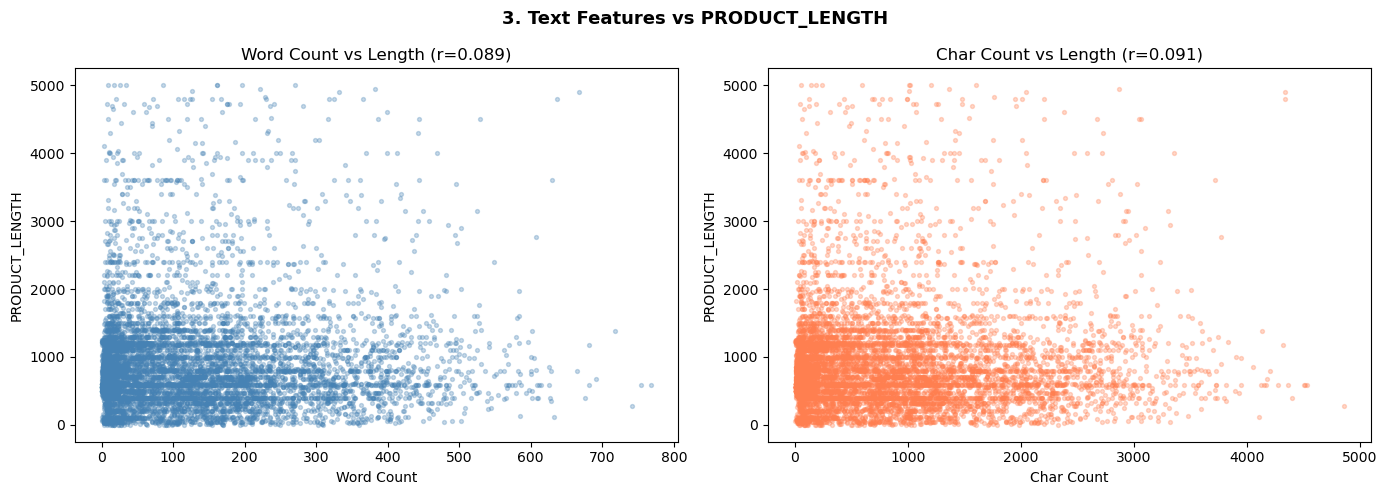

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("3. Text Features vs PRODUCT_LENGTH", fontsize=13, fontweight="bold")
# Scatter (sample 5k for speed)
s = df.sample(min(10000, len(df)), random_state=42)
axes[0].scatter(s["WORD_COUNT"], s["PRODUCT_LENGTH"], alpha=0.3, s=8, color="steelblue")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("PRODUCT_LENGTH")
axes[0].set_title(f"Word Count vs Length (r={corr_word:.3f})")

axes[1].scatter(s["CHAR_COUNT"], s["PRODUCT_LENGTH"], alpha=0.3, s=8, color="coral")
axes[1].set_xlabel("Char Count")
axes[1].set_ylabel("PRODUCT_LENGTH")
axes[1].set_title(f"Char Count vs Length (r={corr_char:.3f})")

plt.tight_layout()
plt.savefig("../data/eda_3_text_vs_target.png", dpi=150)
plt.show()


In [87]:
# 3b. Average PRODUCT_LENGTH per PRODUCT_ID_TYPE
avg_per_type = (
    df.groupby("PRODUCT_TYPE_ID")["PRODUCT_LENGTH"]
    .agg(["mean", "median", "std", "count"])
    .reset_index()
    .sort_values("mean", ascending=False)
)
print("\nAvg PRODUCT_LENGTH per PRODUCT_TYPE_ID (top 15):")
print(avg_per_type.head(15).to_string(index=False))


Avg PRODUCT_LENGTH per PRODUCT_TYPE_ID (top 15):
 PRODUCT_TYPE_ID        mean      median        std  count
            7081 4999.999995 4999.999995        NaN      1
            4232 4921.259837 4921.259837        NaN      1
            6421 4899.999998 4899.999998 141.421353      2
            9143 4825.000000 4825.000000        NaN      1
           11957 4803.149601 4803.149601        NaN      1
           10669 4803.149601 4803.149601        NaN      1
            7350 4800.000000 4800.000000        NaN      1
           10927 4800.000000 4800.000000        NaN      1
            9149 4800.000000 4800.000000        NaN      1
           10820 4800.000000 4800.000000        NaN      1
           10995 4800.000000 4800.000000        NaN      1
           10737 4800.000000 4800.000000        NaN      1
            9146 4800.000000 4800.000000        NaN      1
            4410 4800.000000 4800.000000        NaN      1
            7080 4800.000000 4800.000000        NaN      1


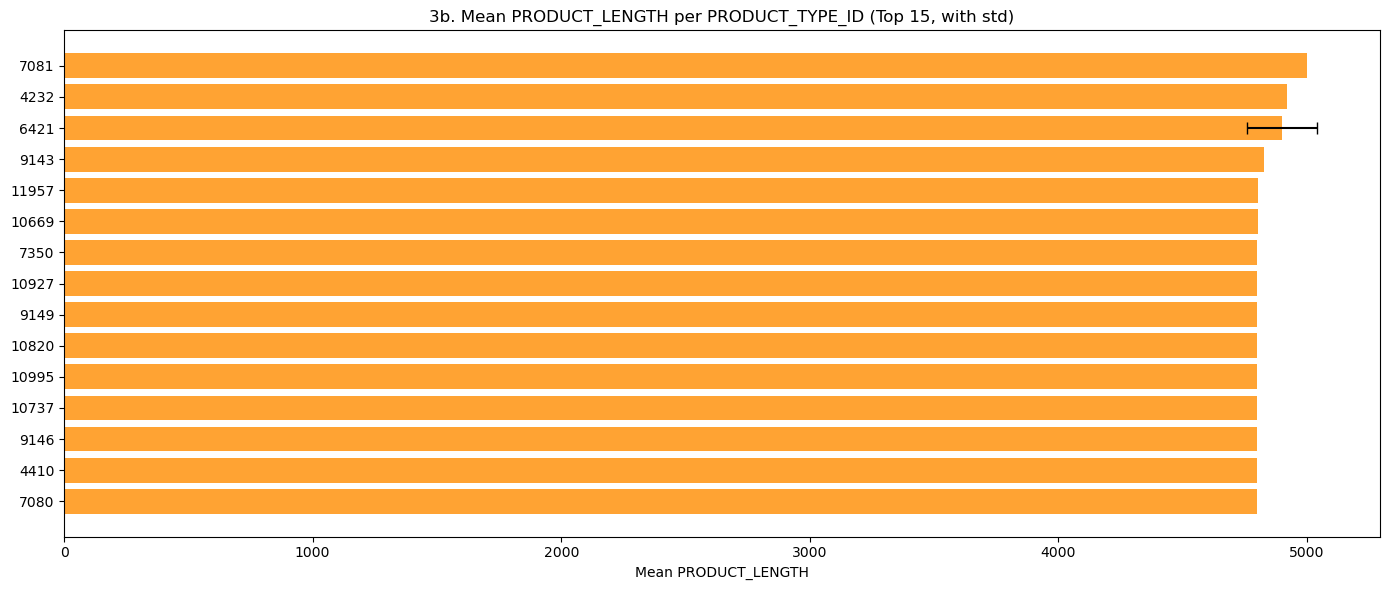

In [89]:
fig, ax = plt.subplots(figsize=(14, 6))
top15 = avg_per_type.head(15)
ax.barh(top15["PRODUCT_TYPE_ID"].astype(str), top15["mean"], xerr=top15["std"],
        color="darkorange", alpha=0.8, capsize=4)
ax.set_title("3b. Mean PRODUCT_LENGTH per PRODUCT_TYPE_ID (Top 15, with std)")
ax.set_xlabel("Mean PRODUCT_LENGTH")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../data/eda_3b_length_per_type.png", dpi=150)
plt.show()

# Label Noise 

In [90]:
type_stats = (
    df.groupby("PRODUCT_TYPE_ID")["PRODUCT_LENGTH"]
    .agg(
        count="count",
        mean="mean",
        std="std",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
    )
    .reset_index()
)

In [91]:
type_stats["IQR"]  = type_stats["q75"] - type_stats["q25"]
type_stats["CV"]   = type_stats["std"] / type_stats["mean"]   # Coefficient of Variation
type_stats = type_stats.sort_values("CV", ascending=False)

In [92]:
print("Categories with highest label noise (CV = std/mean, higher = noisier):")
print(type_stats.head(10).to_string(index=False))

Categories with highest label noise (CV = std/mean, higher = noisier):
 PRODUCT_TYPE_ID  count        mean         std        q25         q75         IQR       CV
            8384     13  470.000000 1195.070082   1.000000    1.000000    0.000000 2.542702
             705     10  751.299142 1428.909682 118.110236  636.082500  517.972264 1.901918
            3682      4 1209.842520 2194.437993  84.842520 1275.000000 1190.157480 1.813821
           12157     71  332.378506  602.315991 118.110236  307.480315  189.370079 1.812139
            2206     56  296.397632  513.581519 157.480315  314.960630  157.480315 1.732745
            8302      4  906.011810 1512.149978   1.000000 1141.732282 1140.732282 1.669018
           12061      6 1076.115484 1787.707951 314.960630  393.700787   78.740157 1.661260
           11074      8  791.927165 1309.226438  93.750000  642.716535  548.966535 1.653216
            1647     14 1060.714286 1655.750884 200.000000  781.250000  581.250000 1.560977
         

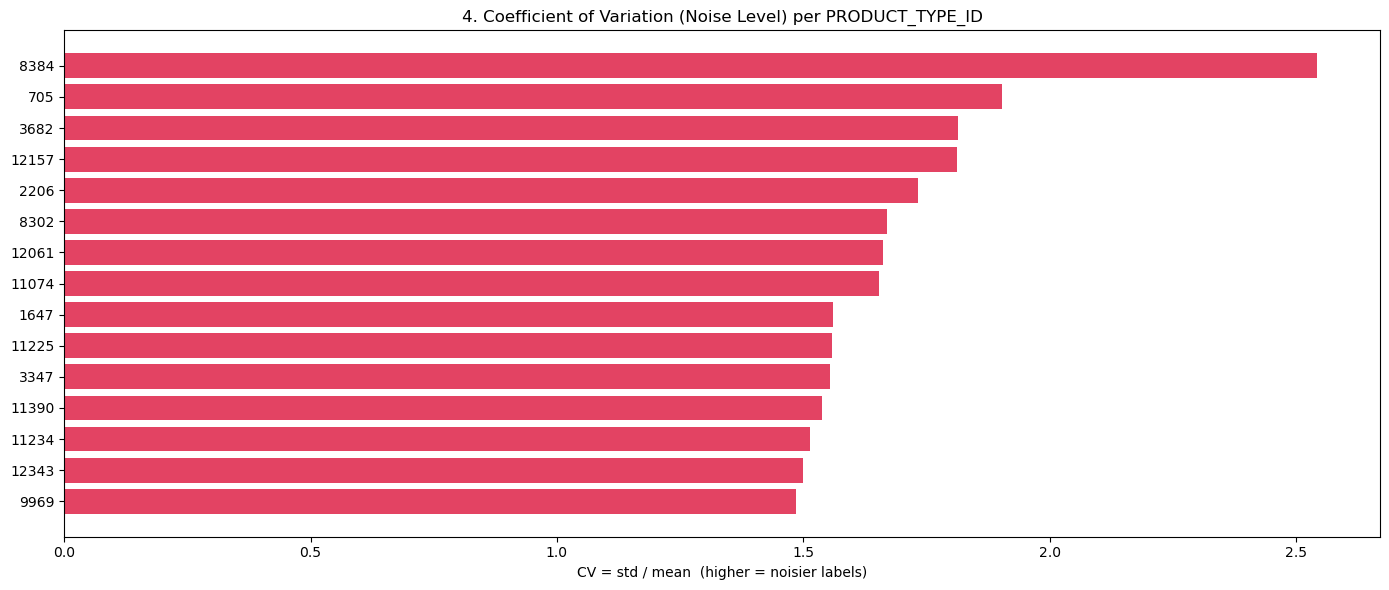

In [94]:
fig, ax = plt.subplots(figsize=(14, 6))
top_noisy = type_stats.head(15)
ax.barh(top_noisy["PRODUCT_TYPE_ID"].astype(str), top_noisy["CV"], color="crimson", alpha=0.8)
ax.set_title("4. Coefficient of Variation (Noise Level) per PRODUCT_TYPE_ID")
ax.set_xlabel("CV = std / mean  (higher = noisier labels)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../data/eda_4_label_noise_per_category.png", dpi=150)
plt.show()


In [95]:
df[df['PRODUCT_TYPE_ID']==8384]

,PRODUCT_ID,PRODUCT_TYPE_ID,PRODUCT_LENGTH,TOTAL_SENTENCE,HAS_HTML,WORD_COUNT,CHAR_COUNT
5466,2989918,8384,1.0,Shilpi Handicrafts Mango Wood & MDF Room Divid...,False,170,1025
18861,2537459,8384,1.0,Woodasia Handcrafted 4 Panel Wooden Room parti...,False,159,977
19055,2094782,8384,2000.0,TAYYABA ENTERPRISES Wooden Partition for Livin...,False,271,1631
25203,2473207,8384,1.0,CRAFT DECOR Wooden Rooms Partition for Living ...,False,154,1049
33125,2463267,8384,1.0,"8 Panel Room Divider, Wooden Privacy Screen Pa...",True,204,1325
40063,1609515,8384,1.0,VERSARE Room Divider 360 Accordian Portable Pa...,True,250,1705
41870,1612776,8384,1.0,VERSARE StraightWall Sliding Portable Partitio...,True,243,1635
42876,2312423,8384,4000.0,S&S Wooden Room Divider Partition Separator fo...,False,239,1436
45411,1609390,8384,1.0,VERSARE Room Divider 360 Accordian Portable Pa...,True,250,1704
46236,2579259,8384,1.0,onlinecraft Wooden Partition Screen /Room Divi...,False,166,962


## Class Imbalance in PRODUCT_TYPE_ID

In [97]:
vc = df["PRODUCT_TYPE_ID"].value_counts(normalize=True) * 100
cumsum = vc.cumsum()
top5_pct  = cumsum.iloc[4]  if len(cumsum) > 4 else cumsum.iloc[-1]
top10_pct = cumsum.iloc[9]  if len(cumsum) > 9 else cumsum.iloc[-1]

print(f"Total unique PRODUCT_TYP_IDs : {df['PRODUCT_TYPE_ID'].nunique()}")
print(f"Top-5  categories cover       : {top5_pct:.1f}% of data")
print(f"Top-10 categories cover       : {top10_pct:.1f}% of data")
print("→ If top-5 cover >80%, consider stratified sampling for train/val.")

Total unique PRODUCT_TYP_IDs : 5190
Top-5  categories cover       : 13.2% of data
Top-10 categories cover       : 17.6% of data
→ If top-5 cover >80%, consider stratified sampling for train/val.


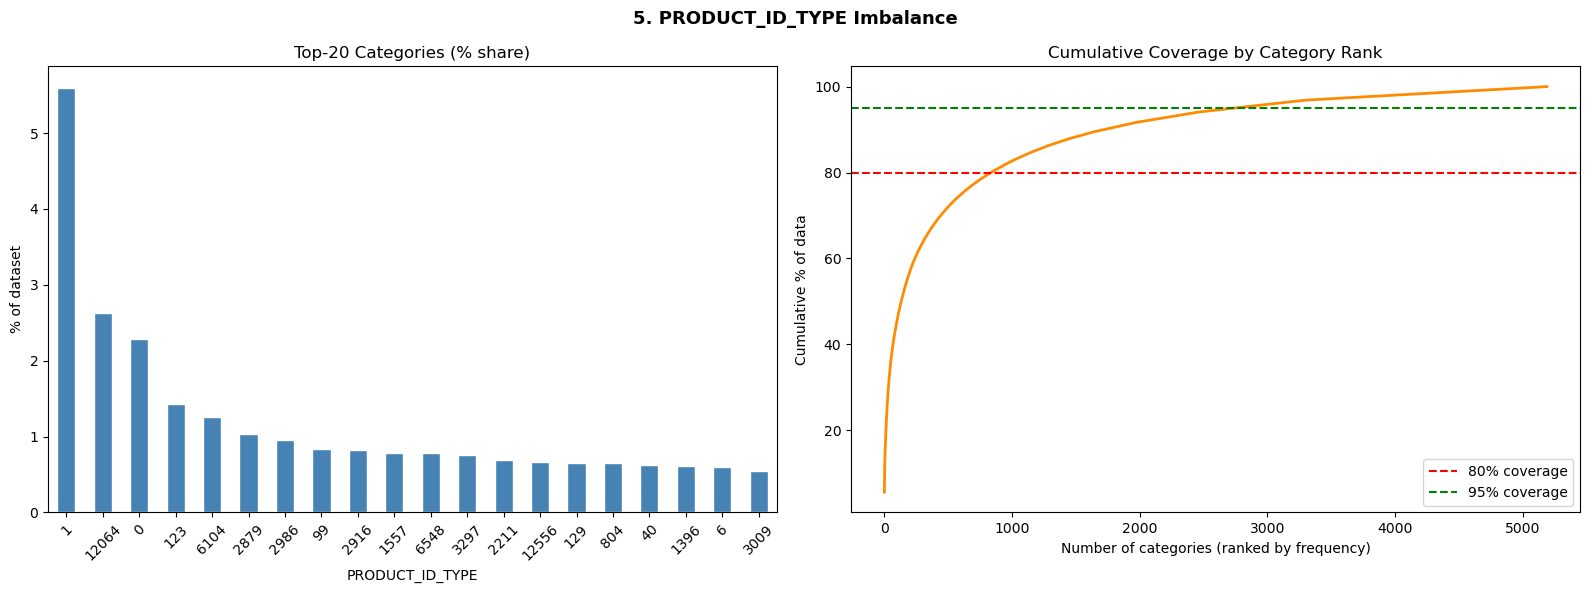

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("5. PRODUCT_ID_TYPE Imbalance", fontsize=13, fontweight="bold")

vc.head(20).plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Top-20 Categories (% share)")
axes[0].set_xlabel("PRODUCT_ID_TYPE")
axes[0].set_ylabel("% of dataset")
axes[0].tick_params(axis="x", rotation=45)
# Lorenz-style cumulative coverage
axes[1].plot(range(1, len(cumsum)+1), cumsum.values, color="darkorange", linewidth=2)
axes[1].axhline(80, color="red", linestyle="--", label="80% coverage")
axes[1].axhline(95, color="green", linestyle="--", label="95% coverage")
axes[1].set_title("Cumulative Coverage by Category Rank")
axes[1].set_xlabel("Number of categories (ranked by frequency)")
axes[1].set_ylabel("Cumulative % of data")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/eda_5_class_imbalance.png", dpi=150)
plt.show()

## TF-IDF KEYWORD ANALYSIS PER CATEGORY

In [100]:
# Check if unit keywords appear in descriptions
unit_keywords = ["cm", "inch", "mm", "meter", "feet", "ft", "centimeter", "inches"]
for kw in unit_keywords:
    count = df["TOTAL_SENTENCE"].fillna("").str.lower().str.contains(rf"\b{kw}\b").sum()
    pct   = count / len(df) * 100
    print(f"  '{kw}' found in {count:,} rows ({pct:.2f}%)")

print("\n→ If unit keywords appear in >20% rows, regex feature extraction will help your model.")

  'cm' found in 2,460 rows (4.10%)
  'inch' found in 4,990 rows (8.32%)
  'mm' found in 985 rows (1.64%)
  'meter' found in 327 rows (0.55%)
  'feet' found in 1,626 rows (2.71%)
  'ft' found in 289 rows (0.48%)
  'centimeter' found in 14 rows (0.02%)
  'inches' found in 3,266 rows (5.44%)

→ If unit keywords appear in >20% rows, regex feature extraction will help your model.


In [117]:
# give me an example of a description that contains the word "cm"
example_cm = df[df["TOTAL_SENTENCE"].fillna("").str.lower().str.contains(r"\bmeter\b")]['PRODUCT_LENGTH'].iloc[1]
print(f"\nExample description containing 'inch':\n{example_cm}")


Example description containing 'inch':
708.6614166



Top TF-IDF terms per category (top 5 categories):


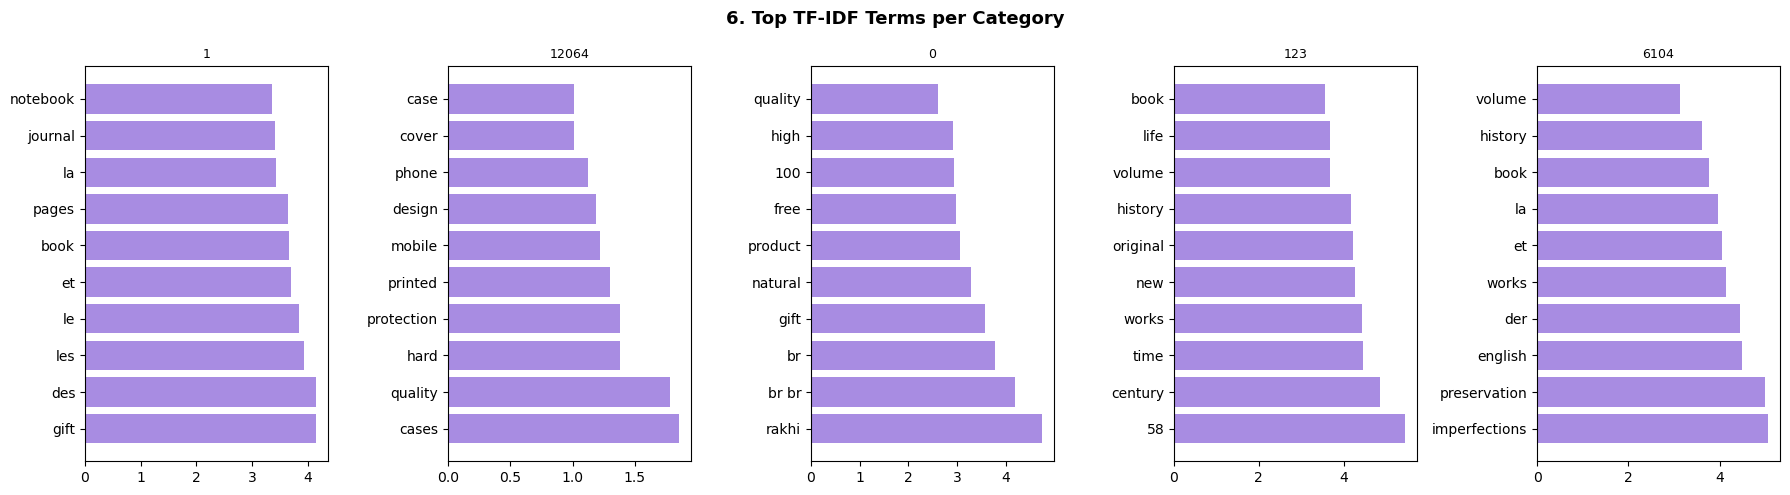

In [120]:


# TF-IDF top terms per top-5 categories
top_categories = df["PRODUCT_TYPE_ID"].value_counts().head(5).index.tolist()
print("\nTop TF-IDF terms per category (top 5 categories):")
fig, axes = plt.subplots(1, len(top_categories), figsize=(18, 5))
fig.suptitle("6. Top TF-IDF Terms per Category", fontsize=13, fontweight="bold")

for i, cat in enumerate(top_categories):
    cat_texts = df[df["PRODUCT_TYPE_ID"] == cat]["TOTAL_SENTENCE"].fillna("").tolist()
    if len(cat_texts) < 5:
        continue
    tfidf = TfidfVectorizer(max_features=10, stop_words="english", ngram_range=(1, 2))
    try:
        tfidf.fit(cat_texts)
        terms  = tfidf.get_feature_names_out()
        scores = tfidf.idf_  # inverse doc freq as proxy for importance
        # sort by idf ascending (lower idf = more important in this corpus)
        sorted_idx = np.argsort(scores)
        top_terms  = [terms[j] for j in sorted_idx[:10]]
        top_scores = [scores[j] for j in sorted_idx[:10]]

        axes[i].barh(top_terms, top_scores, color="mediumpurple", alpha=0.8)
        axes[i].set_title(f"{str(cat)[:20]}", fontsize=9)
        axes[i].invert_yaxis()
    except Exception as e:
        print(f"  Skipping {cat}: {e}")

plt.tight_layout()
plt.savefig("../data/eda_6_tfidf_per_category.png", dpi=150)
plt.show()